# OT-2: Gas Generator Combustion Modelling & Parametric Study

In [19]:
import handcalcs.render
import numpy as np
import matplotlib.pyplot as plt

from rocketcea.cea_obj_w_units import CEA_Obj
from turborocket.combustion.comb_solver import CombustionCantera
import CoolProp.CoolProp as CP

In [20]:
t = CP.PropsSI("T", "P", 15e5, "Q", 1, "NitrousOxide")

In [21]:
print(t-273.15)

-25.918909391724895


In [22]:
rho = CP.PropsSI("D", "T", t, "P", 41e5, "NitrousOxide")

In [39]:
print(rho)

1031.705127412103


$$ T = \dot{m} v_t + A ( P_t - P_{amb} ) $$

$$ T = \dot{m} \sqrt{\gamma R T} + A ( P_t - P_{amb} ) $$

$$ T = (\dot{m}_f + \dot{m}_o)  \sqrt{\gamma R T} + A ( P_t - P_{amb} ) $$

Author: Elias Aoubala

Date: 22/02/2026

## 1 - Background

This document contains the authors analysis and combustion modelling for the `OT-2: Man-Ray and The Dirty Bubble` turbopump. The main aim of this document is to conduct the parameteric study and sensitivity to see how the combustion parameters vary under a range of propellant mixture ratios and chamber pressures.

For this combustion modelling, we will be using both `CEA` via the python wrapper `rocketCEA` and our in-house built chemical mechanism file via the `cantera` library.

## 2 - Theoretical Combustion Study

One of the first steps that needs to be conducted in the sizing of the two components is to decided what the mixture ratio of the gas generator is. This is mainly driven on material requirements, with a maximum combustion gas temperature being acceptable.

In this study, we will do side-by-side comparisons of our implementation of the combustion modelling, with that using the well-established tool, `CEA`, to confirm the calculations are indeed reasonable.

### 2.1 - Combustion Objects Instantiation

Here, we can setup our two objects used for doing the combustion modelling.

Firstly, we instanatiate our rocket CEA object, using the following propellant names (as these differ to that used by our Cantera model):

In [24]:
%%render

fuel_cea = "Isopropanol"

ox_cea = "N2O"


<IPython.core.display.Latex object>

We can now instantiate our CEA object. By default, `rocketcea` tends to use empirical performance parameters. As such, we configure the object at instantiation to use common SI Units (with the exception of pressure, which is written in Bar for convenience).

In [25]:
cea = CEA_Obj(
    oxName=ox_cea,
    fuelName=fuel_cea,
    pressure_units="Bar",
    temperature_units="K",
    density_units="kg/m^3",
    specific_heat_units="J/kg-K",
)

For our `cantera` model, we will be extracting it from the combustion sub-module of the `turborocket` library. In this case, we define the propellant names for the Nitrous Oxide and IPA here. In addition, for the Cantera model, we must provide a species/mechanism file, to enable for the gibbs free energy minimization. We similarly define the name of the file (which should be contained in the same folder as this jupyter notebook) as follows:

In [28]:
%%render

fuel_ctr = "C3H8O,2propanol"

ox_ctr = "N2O"

species_file = "config/n2o_ipa.yaml"


<IPython.core.display.Latex object>

We can now define our Cantera combustion object.

In [29]:
ctr = CombustionCantera(fuel = fuel_ctr,
                        oxidiser = ox_ctr,
                        species_file = species_file)

We have now instantiated our combustion objects, that we can use for our analysis.

### 2.2 - Pressure and Mixture Ratio Range Definition

As the gas-generator is intended to be used on a small turbopump, we will limit our selves to a relatively low range of combustion pressures. For the mixture ratio, we will perform the analysis as far up as mixture ratio of 6 (where there is very little solid carbon formation), to enable validation of the model.

In [30]:
p_array = np.linspace(10, 35, 4) * 1e5 # Pa

MR_array = np.arange(0.25, 6, 0.25)

p_array, MR_array = np.meshgrid(p_array, MR_array)

### 2.2 - Combustion Temperature

For our first parameteric study, we can evaluate for the variation in combustion temperatures as a function of Mixture Ratio and combustion pressure.

It should be noted that no impact for rayleigh flow (gas accelerating in the combustion chamber from stagnation conditions) has been considered, with this study only being performed under assumed stagnation conditions.

In [32]:
to_cea_array = np.zeros(p_array.shape)

to_ctr_array = np.zeros(p_array.shape)

deviation_array = np.zeros(p_array.shape)

for index, val in np.ndenumerate(p_array):
    
    # We extract our pressure and mixture ratio
    p = p_array[index]
    mr = MR_array[index]

    # We then get the cea and cantera combustio conditions
    to_cea_array[index] = cea.get_Temperatures(Pc=p/1e5, MR=mr)[0]

    to_ctr_array[index] = ctr.get_thermo_prop(
        Pcc=p, MR=mr, frozen=False
    ).t
    
    # We can accordingly compute for the deviations in the relative deviations of the two results
    deviation_array[index] = abs(to_cea_array[index]-to_ctr_array[index])/to_ctr_array[index]

ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

We can get our maximum expected deviation and report it below:

In [33]:
max_dev = deviation_array.max()*100

print(f"Maximum Result Deviation: {max_dev:.2f} %")

Maximum Result Deviation: 0.15 %


We can now plot our results side-by-side.

Text(0.5, 0.98, 'Variation of Combustion Temperature with MR')

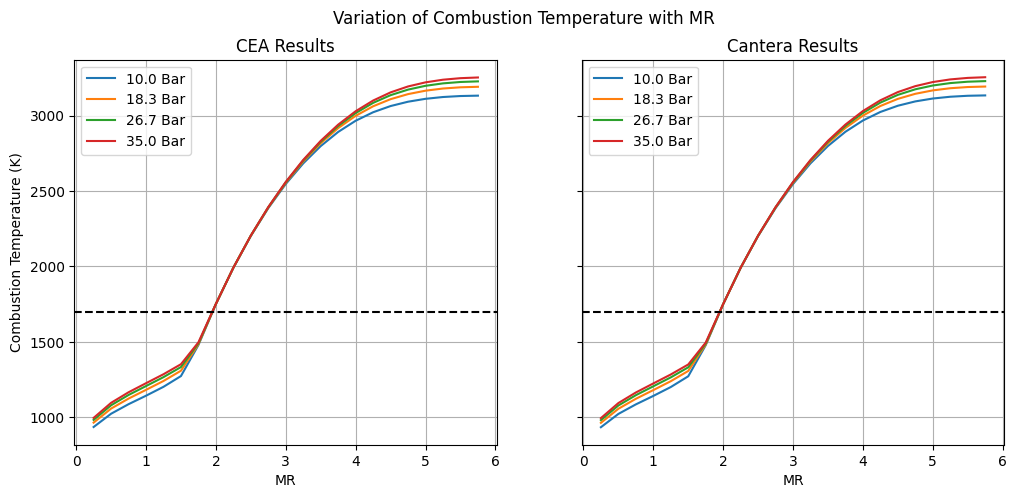

In [38]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], to_cea_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], to_ctr_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results")
axs[1].set_title("Cantera Results")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel("Combustion Temperature (K)")

axs[0].grid()
axs[1].grid()

axs[0].axhline(1700, color="k", linestyle="--")
axs[1].axhline(1700, color="k", linestyle="--")

fig.suptitle("Variation of Combustion Temperature with MR")

### 2.3 - Specific Heat Capacity

Another quite improtant parameter to consider is the specific heat capacity of the gas, this will have critical implications on the required mass flow rate needed for the gas generator.

We similarly iterate through the same pressure ranges to extract the following:

In [ ]:
cp_cea_array = np.zeros(p_array.shape)

cp_ctr_array = np.zeros(p_array.shape)

cp_deviation_array = np.zeros(p_array.shape)

for index, val in np.ndenumerate(p_array):

    p = p_array[index]
    
    mr = MR_array[index]

    cp_cea_array[index] = cea.get_Chamber_Cp(Pc=p/1e5, MR=mr, frozen=1)

    cp_ctr_array[index] = ctr.get_thermo_prop(Pcc=p, MR=mr, frozen=True).get_cp()

    cp_deviation_array[index] = abs(cp_cea_array[index] - cp_ctr_array[index]) / cp_ctr_array[index]


ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

We can now plot our deviations between the two results:

In [ ]:
max_deviation = cp_deviation_array.max()*100

print(f"Max deviation: {max_deviation:.1f} %")

Max deviation: 11.0 %


Text(0.5, 0.98, 'Variation of Specific Heat Capaciy, $C_p$, with MR')

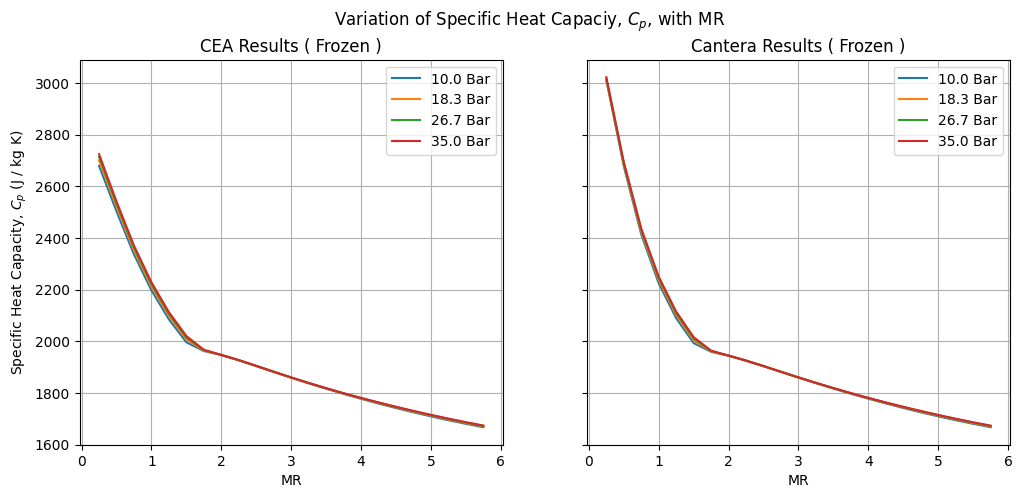

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], cp_cea_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], cp_ctr_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results ( Frozen )")
axs[1].set_title("Cantera Results ( Frozen )")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel("Specific Heat Capacity, $C_p$ (J / kg K)")

axs[0].grid()
axs[1].grid()

fig.suptitle("Variation of Specific Heat Capaciy, $C_p$, with MR")

### 2.4 - Specific Heat Ratio

Another key parameter that is influential to the design of the turbopump, is the specific heat ratio ($\gamma$), which has been plotted below.

In [ ]:
gamma_cea_array = np.zeros(p_array.shape)

gamma_ctr_array = np.zeros(p_array.shape)

gamma_deviation_array = np.zeros(p_array.shape)

for index, val in np.ndenumerate(p_array):

    p = p_array[index]
    
    mr = MR_array[index]

    gamma_cea_array[index] = cea.get_Chamber_MolWt_gamma(Pc=p/1e5, MR=mr)[1]

    gamma_ctr_array[index] = ctr.get_thermo_prop(Pcc=p, MR=mr, frozen=True).get_gamma()

    gamma_deviation_array[index] = abs(gamma_cea_array[index] - gamma_ctr_array[index]) / gamma_ctr_array[index]


ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

We can now plot our deviations between the two results:

In [ ]:
max_deviation = gamma_deviation_array.max()*100

print(f"Max deviation: {max_deviation:.1f} %")

Max deviation: 11.1 %


Text(0.5, 0.98, 'Variation of Specific Heat Ratio, $\\gamma$, with MR')

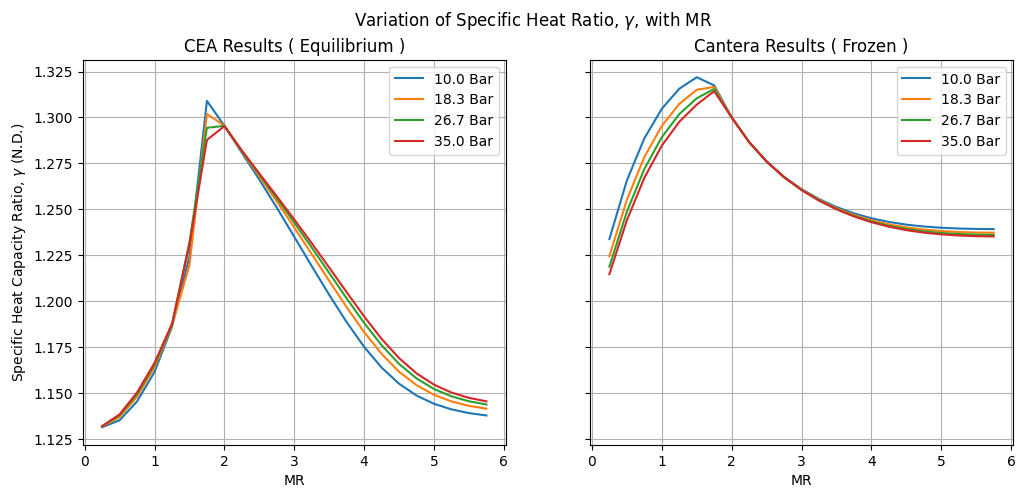

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], gamma_cea_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], gamma_ctr_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results ( Equilibrium )")
axs[1].set_title("Cantera Results ( Frozen )")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel(r"Specific Heat Capacity Ratio, $\gamma$ (N.D.)")

axs[0].grid()
axs[1].grid()

fig.suptitle(r"Variation of Specific Heat Ratio, $\gamma$, with MR")

### 2.5 - Specific Gas Constant

The specific gas constant is an important parameter, as this will directly influence the gas generator exhaust density and thus areas producted for both the rotor and the stator.

Two approaches are taken here:

- Gas constant, as reported from the combustion solver
- Gas constant assuming Ideal gas conditions (derived via specific heat ratio and specific heat capacity)

#### 2.5.1 - Extracted from Combustion Solver

We will just extract the results straight from the solver here.

In [ ]:
r_cea_d_array = np.zeros(p_array.shape)

r_ctr_d_array = np.zeros(p_array.shape)

r_deviation_d_array = np.zeros(p_array.shape)

R_univ = 8314


for index, value in np.ndenumerate(p_array):
    
    p = p_array[index]
    mr = MR_array[index]

    r_cea_d_array[index] = R_univ / cea.get_Chamber_MolWt_gamma(Pc=p/1e5, MR=mr)[0]

    r_ctr_d_array[index] = ctr.get_thermo_prop(Pcc=p, MR=mr, frozen=True).get_R()

    r_deviation_d_array[index] = abs(r_cea_d_array[index] - r_ctr_d_array[index])/r_ctr_d_array[index]


ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

In [ ]:
max_deviation = r_deviation_d_array.max()*100

print(f"Max deviation: {max_deviation:.1f} %")

Max deviation: 7.3 %


Text(0.5, 0.98, 'Variation of Specific Heat Ratio, $R$, with MR')

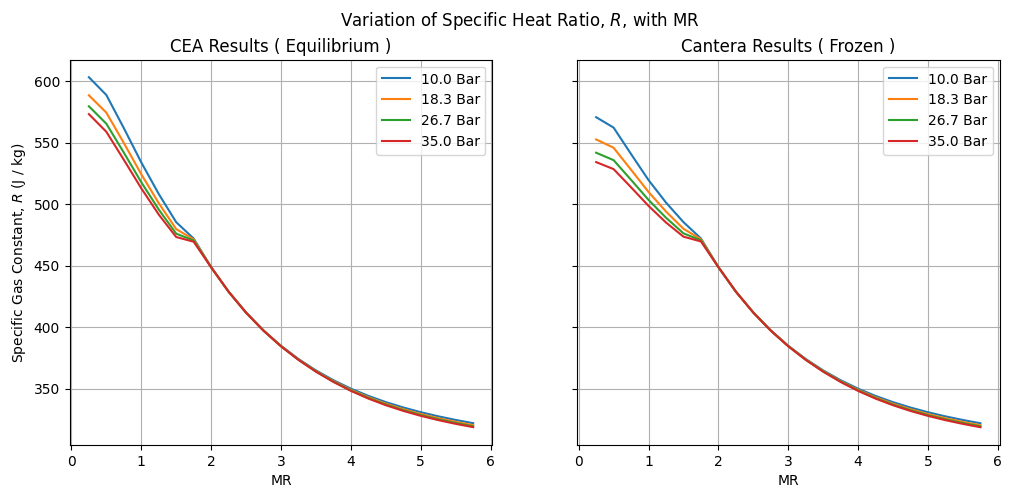

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], r_cea_d_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], r_ctr_d_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results ( Equilibrium )")
axs[1].set_title("Cantera Results ( Frozen )")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel(r"Specific Gas Constant, $R$ (J / kg)")

axs[0].grid()
axs[1].grid()

fig.suptitle(r"Variation of Specific Heat Ratio, $R$, with MR")

#### 2.5.2 - Derivied from Ideal Gas Assumption

We will just extract the results straight from the solver here.

In [ ]:
r_cea_id_array = np.zeros(p_array.shape)

r_ctr_id_array = np.zeros(p_array.shape)

r_deviation_id_array = np.zeros(p_array.shape)

R_univ = 8314


for index, value in np.ndenumerate(p_array):
    
    p = p_array[index]
    mr = MR_array[index]

    gamma_cea = cea.get_Chamber_MolWt_gamma(Pc=p/1e5, MR=mr)[1]
    cp_cea = cea.get_Chamber_Cp(Pc=p/1e5, MR=mr, frozen=1)

    ctr_obj = ctr.get_thermo_prop(Pcc=p, MR=mr, frozen=True)

    gamma_ctr = ctr_obj.get_gamma()
    cp_ctr = ctr_obj.get_cp()

    r_cea_id_array[index] = cp_cea * (gamma_cea - 1)/gamma_cea

    r_ctr_id_array[index] = cp_ctr * (gamma_ctr - 1)/gamma_ctr

    r_deviation_id_array[index] = abs(r_cea_id_array[index] - r_ctr_id_array[index])/r_ctr_id_array[index]


ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

In [ ]:
max_deviation = r_deviation_id_array.max()*100

print(f"Max deviation: {max_deviation:.1f} %")

Max deviation: 47.0 %


Text(0.5, 0.98, 'Variation of Specific Heat Ratio, $R$, with MR')

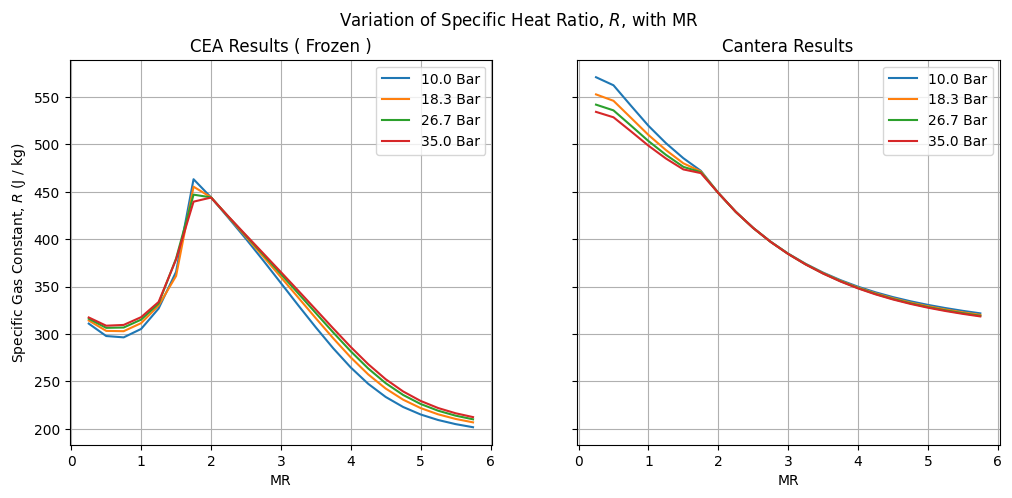

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], r_cea_id_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], r_ctr_id_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results ( Frozen )")
axs[1].set_title("Cantera Results")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel(r"Specific Gas Constant, $R$ (J / kg)")

axs[0].grid()
axs[1].grid()

fig.suptitle(r"Variation of Specific Heat Ratio, $R$, with MR")

## 3 - Expected Performance Modelling

The previous study mainly focused on the theoretical performance results from the combustion, but in this section, we aim to evaluate for what the expected behaviours of the gas-generator will be across the wide range of combustion values we have investigated - accounting for real performance metrics such as c* efficiency (from mixing), along with the evaluation of more complex paramaters such as expected throat pressures.

### 3.1 - Combustion Objects Instantiation

Similar to what was done previously, we will setup our combustion objects for our evaluations

In [ ]:
%%render

fuel_cea = "Isopropanol"

ox_cea = "N2O"


<IPython.core.display.Latex object>

Instantiating our CEA object using SI units (except for pressure):

In [ ]:
cea = CEA_Obj(
    oxName=ox_cea,
    fuelName=fuel_cea,
    pressure_units="Bar",
    temperature_units="K",
    density_units="kg/m^3",
    specific_heat_units="J/kg-K",
)

Similarly, we define the propellant names for our cantera mechanism:

In [ ]:
%%render

fuel_ctr = "C3H8O,2propanol"

ox_ctr = "N2O"

species_file = "n2o_ipa.yaml"


<IPython.core.display.Latex object>

We can now define our Cantera combustion object.

In [ ]:
ctr = CombustionCantera(fuel = fuel_ctr,
                        oxidiser = ox_ctr,
                        species_file = species_file)

We have now instantiated our combustion objects, that we can use for our analysis.

### 3.2 - Pressure and Mixture Ratio Range Definition

As the gas-generator is intended to be used on a small turbopump, we will limit our selves to a relatively low range of combustion pressures. For the mixture ratio, we will mainly focus on the low-end relevant for the gas-generator, up to approximately 3.

In [ ]:
p_array = np.linspace(10, 35, 4) * 1e5 # Pa

MR_array = np.arange(0.1, 3, 0.1)

p_array, MR_array = np.meshgrid(p_array, MR_array)

### 3.3 - Characteristic Velocity (c*)

The characteristic velocity is a key parameter describing the normalised mass flow rate and pressure of a given chamber. It is commonly used as a benchmark for evaluating how well a combustion has been designed. For this parameter, a standard ideal gas evaluation has been used, with the following defintion being derived:



$c^* = \frac{P_c A_t}{\dot{m}}$

$c^* = \sqrt{\frac{T R}{\gamma} \left( \frac{\gamma + 1}{2} \right) ^{\frac{\gamma + 1}{\gamma -1 }})}$

For brevity, the full derivation has not been included. This can be derived using the standard choked mass flow equation through an orifice from an ideal gas, following the definition of the c*, as stated in the first equation

In [ ]:
c_star_cea_cstar_array = np.zeros(p_array.shape)

c_star_ctr_cstar_array = np.zeros(p_array.shape)

c_star_deviation_array = np.zeros(p_array.shape)

for index, val in np.ndenumerate(p_array):
    
    # We extract our pressure and mixture ratio
    p = p_array[index]
    mr = MR_array[index]

    ctr_obj = ctr.get_thermo_prop(Pcc=p, MR=mr, frozen=True)

    gamma_cea = cea.get_Chamber_MolWt_gamma(Pc=p/1e5, MR=mr)[1]
    gamma_ctr = ctr_obj.get_gamma()
    
    to_cea = cea.get_Temperatures(Pc=p/1e5, MR=mr)[0]
    to_ctr = ctr_obj.get_temperature()
    
    r_cea = R_univ / cea.get_Chamber_MolWt_gamma(Pc=p/1e5, MR=mr)[0]
    r_ctr =ctr_obj.get_R()

    # We then get the cea and cantera combustio conditions
    c_star_cea_cstar_array[index] = ( ((to_cea * r_cea) / gamma_cea) * ((gamma_cea + 1) / 2)**((gamma_cea + 1) / (gamma_cea - 1)) )**(1/2)

    c_star_ctr_cstar_array[index] = ( ((to_ctr * r_ctr) / gamma_ctr) * ((gamma_ctr + 1) / 2)**((gamma_ctr + 1) / (gamma_ctr - 1)) )**(1/2)
    
    # We can accordingly compute for the deviations in the relative deviations of the two results
    c_star_deviation_array[index] = abs(c_star_cea_cstar_array[index] - c_star_ctr_cstar_array[index])/c_star_ctr_cstar_array[index]

ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

We can get our maximum expected deviation and report it below:

In [ ]:
max_dev = c_star_deviation_array.max()*100

print(f"Maximum Result Deviation: {max_dev:.2f} %")

Maximum Result Deviation: 6.53 %


We can now plot our results side-by-side.

Text(0.5, 0.98, 'Variation of Characteristic Velocity, c*, with MR')

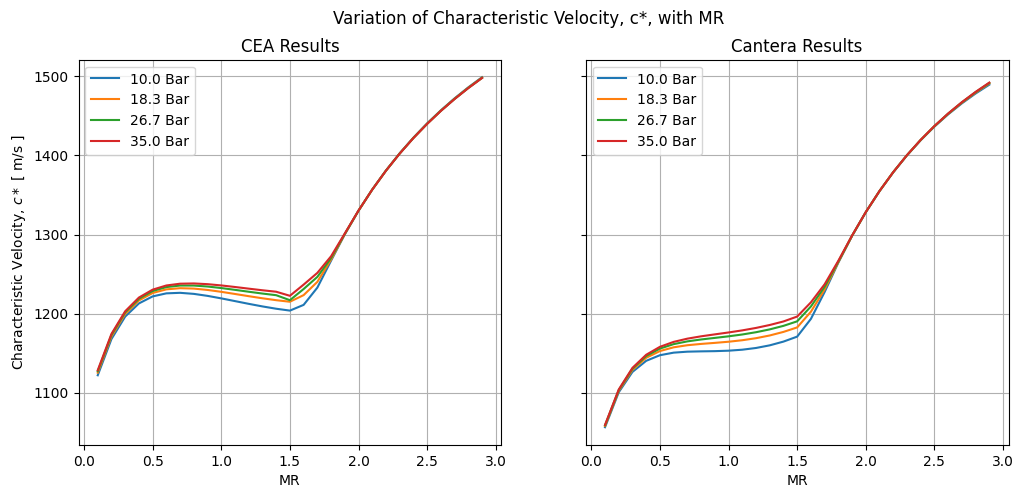

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], c_star_cea_cstar_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], c_star_ctr_cstar_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results")
axs[1].set_title("Cantera Results")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel(r"Characteristic Velocity, $c*$ [ m/s ]")

axs[0].grid()
axs[1].grid()

fig.suptitle(rf"Variation of Characteristic Velocity, c*, with MR")

### 3.4 - Combustion Temperature accounting for C* Efficiency

One of the key performance metrics relevant to combustion device performance evaluation is the `c* efficiency`. The c* efficiency effectively describes how well the mixing is performed in the gas-generator, relative to an idealised perfect combustion case, as evaluated previously.

The characteristic velocity is defined as the following:

$c^* = \frac{P_c A_t}{\dot{m}}$

We can derive the relationship between c* and the gas temperature to be as follows:

$c^* = \sqrt{\frac{T R}{\gamma} \left( \frac{\gamma + 1}{2} \right) ^{\frac{\gamma + 1}{\gamma -1 }})}$

We can assume thay any efficiency impact has negligible impact to the specific heat ratio of the specific gas constant of the resultant mixture, but only with the combustion temperature. Hence we can derive the following relationship for the $c^*$ efficiency with combustion temperature

$\eta_{c^*} = \frac{c^*_{act}}{c^*_{theo}} = \frac{\sqrt{T_{act}}}{\sqrt{T_{theo}}}$

Thus we can derive the actual combustion temperature as follows:

$T_{act} = T_{theo} \eta_{c^*}^2$


As can be seen, the c* efficiency has second order impact effects on the combustion temperature and hence should be considered.

For this study, the following c* efficiency has been assumed:

In [ ]:
%%render params

eta_c_star = 0.9

<IPython.core.display.Latex object>

In [ ]:
to_cea_cstar_array = np.zeros(p_array.shape)

to_ctr_cstar_array = np.zeros(p_array.shape)

to_deviation_array = np.zeros(p_array.shape)

for index, val in np.ndenumerate(p_array):
    
    # We extract our pressure and mixture ratio
    p = p_array[index]
    mr = MR_array[index]

    # We then get the cea and cantera combustio conditions
    to_cea_cstar_array[index] = cea.get_Temperatures(Pc=p/1e5, MR=mr)[0] * eta_c_star**2

    to_ctr_cstar_array[index] = ctr.get_thermo_prop(
        Pcc=p, MR=mr, frozen=False
    ).get_temperature() * eta_c_star**2
    
    # We can accordingly compute for the deviations in the relative deviations of the two results
    to_deviation_array[index] = abs(to_cea_cstar_array[index]-to_ctr_cstar_array[index])/to_ctr_cstar_array[index]

ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

We can get our maximum expected deviation and report it below:

In [ ]:
max_dev = to_deviation_array.max()*100

print(f"Maximum Result Deviation: {max_dev:.2f} %")

Maximum Result Deviation: 0.15 %


We can now plot our results side-by-side.

Text(0.5, 0.98, 'Variation of Combustion Temperature with MR @ $\\eta_c$ = 90.0 %')

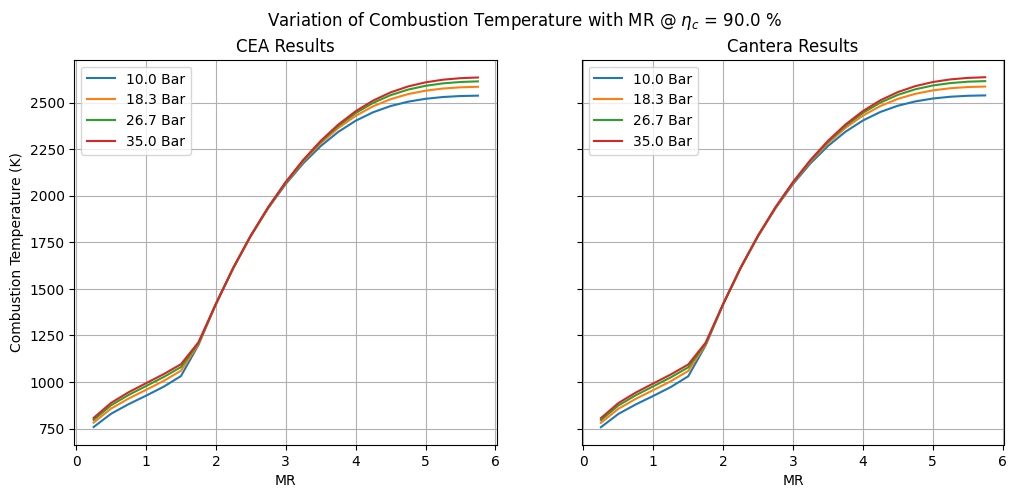

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], to_cea_cstar_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], to_ctr_cstar_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results")
axs[1].set_title("Cantera Results")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel("Combustion Temperature (K)")

axs[0].grid()
axs[1].grid()

fig.suptitle(rf"Variation of Combustion Temperature with MR @ $\eta_c$ = {eta_c_star*100:.1f} %")

### 3.5 - Choking Pressure Ratio

One common parameter that is used in nozzle design often is the evaluation of the expected choking pressure ratio. Hence, similar to the previous plots, we aim to evaluate for this. We will employ standard ideal gas assumptions, with the choking pressure ratio defined as the following:


$$\frac{p*}{p_o} = \left( \frac{2}{\gamma + 1} \right)^{\frac{\gamma}{\gamma - 1}}$$

In [ ]:
p_rat_cea_cstar_array = np.zeros(p_array.shape)

p_rat_ctr_cstar_array = np.zeros(p_array.shape)

p_rat_deviation_array = np.zeros(p_array.shape)

for index, val in np.ndenumerate(p_array):
    
    # We extract our pressure and mixture ratio
    p = p_array[index]
    mr = MR_array[index]

    gamma_cea = cea.get_Chamber_MolWt_gamma(Pc=p/1e5, MR=mr)[1]
    gamma_ctr = ctr.get_thermo_prop(Pcc=p, MR=mr, frozen=True).get_gamma()

    # We then get the cea and cantera combustio conditions
    p_rat_cea_cstar_array[index] = (2 / (gamma_cea + 1))**(gamma_cea / (gamma_cea - 1))

    p_rat_ctr_cstar_array[index] = (2 / (gamma_ctr + 1))**(gamma_ctr / (gamma_ctr - 1))
    
    # We can accordingly compute for the deviations in the relative deviations of the two results
    deviation_array[index] = abs(p_rat_cea_cstar_array[index]-p_rat_ctr_cstar_array[index])/p_rat_ctr_cstar_array[index]

ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
ERROR: FAILURE its = 1001!
E

We can get our maximum expected deviation and report it below:

In [ ]:
max_dev = p_rat_deviation_array.max()*100

print(f"Maximum Result Deviation: {max_dev:.2f} %")

Maximum Result Deviation: 0.00 %


We can now plot our results side-by-side.

Text(0.5, 0.98, 'Variation of Choking Pressure Ratio with MR')

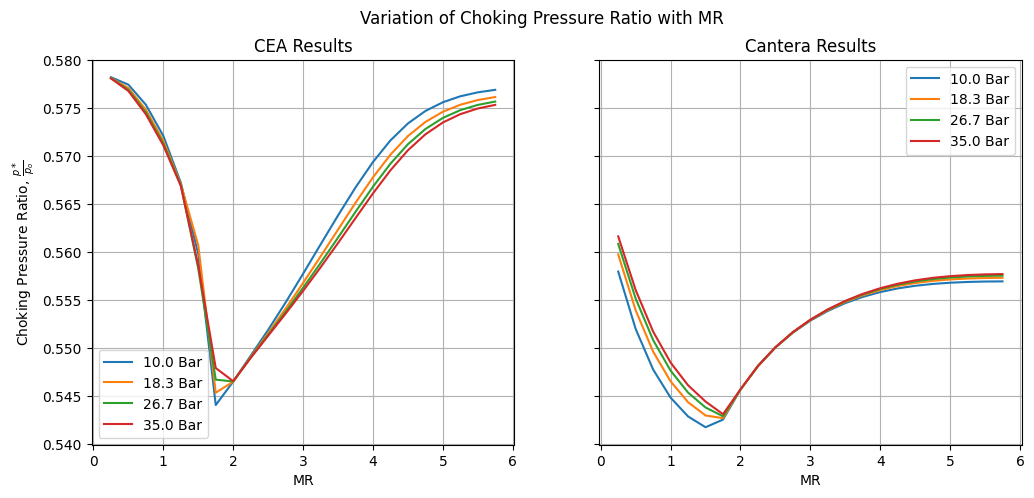

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, sharex= True, sharey=True, figsize=(12,5))

i = 0
for row in MR_array.T:
    
    axs[0].plot(MR_array[:,i], p_rat_cea_cstar_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")
    axs[1].plot(MR_array[:,i], p_rat_ctr_cstar_array[:, i], label=f"{p_array[0,i]/1e5:.1f} Bar")

    i += 1
    
axs[0].legend()
axs[1].legend()

axs[0].set_title("CEA Results")
axs[1].set_title("Cantera Results")

axs[0].set_xlabel("MR")
axs[1].set_xlabel("MR")

axs[0].set_ylabel(r"Choking Pressure Ratio, $\frac{p*}{p_o}$")

axs[0].grid()
axs[1].grid()

fig.suptitle(rf"Variation of Choking Pressure Ratio with MR")